# 02 — Forecasting Baselines

**Goal:** Build the project's chronological train/calibration/test split,
compare a Seasonal Naive baseline against LightGBM, and inspect forecasting errors.

This notebook uses the exact APIs exposed by `src.feature_pipeline.py`
and `src.model_forecaster.py`.

In [1]:
%pip install lightgbm optuna joblib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1 — Imports & Pipeline Loading

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_SEED = 42
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.feature_pipeline import get_splits_and_transformers
from src.model_forecaster import (
    LightGBMForecaster,
    SeasonalNaiveForecaster,
    mae,
    rmse,
    wape,
)

print("Project root:", ROOT)

Project root: c:\Users\Bhavya\Desktop\ML\OptiPerish


## Why a chronological split?

Forecasting is different from ordinary random train/test splitting.

We want:

**past → training → calibration → future test**

The project's `chronological_split()` function creates:

- 70% of unique dates → train
- next 15% → calibration
- final 15% → test

In [3]:
# Cell 2 — Chronological Feature Splitting

(
    X_train,
    y_train,
    X_cal,
    y_cal,
    X_test,
    y_test,
    transformers,
) = get_splits_and_transformers()

print(
    f"Train samples: {len(X_train):,} | "
    f"Calibration samples: {len(X_cal):,} | "
    f"Test samples: {len(X_test):,}"
)

print("\nDate ranges:")
print("Train:", X_train["date"].min(), "to", X_train["date"].max())
print("Cal  :", X_cal["date"].min(), "to", X_cal["date"].max())
print("Test :", X_test["date"].min(), "to", X_test["date"].max())

Train samples: 31,424 | Calibration samples: 6,720 | Test samples: 6,784

Date ranges:
Train: 2024-01-29 00:00:00 to 2025-06-02 00:00:00
Cal  : 2025-06-03 00:00:00 to 2025-09-15 00:00:00
Test : 2025-09-16 00:00:00 to 2025-12-30 00:00:00


## Forecasting features

`src.feature_pipeline.py` creates:

- calendar features
- cyclical day/month encodings
- lag 1, 2, 7, 14, 21 and 28
- shifted rolling means/stds
- a 7-day / 30-day demand ratio
- planned promotional information

The rolling features are shifted by one day so the current target is not used to
construct its own input features.

In [4]:
# Cell 3 — Inspect Engineered Features

feature_preview = X_train.head(5).T
display(feature_preview)

print("\nFeature columns:")
print(X_train.columns.tolist())

,0,1,2,3,4
date,2024-01-29 00:00:00,2024-01-29 00:00:00,2024-01-29 00:00:00,2024-01-29 00:00:00,2024-01-29 00:00:00
store_id,STORE_01,STORE_05,STORE_05,STORE_05,STORE_05
item_id,ITEM_BAKERY_01,ITEM_BAKERY_01,ITEM_BAKERY_02,ITEM_DAIRY_01,ITEM_DAIRY_02
category,Bakery,Bakery,Bakery,Dairy,Dairy
on_promotion,0,0,0,0,0
base_price,49.94,49.36,23.91,60.89,39.65
unit_cost,34.06,33.7,15.06,35.89,20.17
shelf_life_days,3,3,3,7,7
holding_cost_per_day,0.9,0.9,0.33,1.62,0.52
spoilage_cost_per_unit,38.83,39.81,19.25,42.68,28.12



Feature columns:
['date', 'store_id', 'item_id', 'category', 'on_promotion', 'base_price', 'unit_cost', 'shelf_life_days', 'holding_cost_per_day', 'spoilage_cost_per_unit', 'stockout_cost_per_unit', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'is_month_end', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'ratio_mean7_mean30', 'promo_in_next_3days']


## Baseline: Seasonal Naive

For daily grocery demand, the natural weekly benchmark is:

**ŷₜ = yₜ₋₇**

i.e. use the same store-item demand from the previous week.

The baseline is deliberately simple. If a complex ML model cannot beat it,
the added complexity is difficult to justify.

In [5]:
# Cell 4 — Seasonal Naive Baseline

# For a fair future test, the baseline should have access to all historical
# observations available before the test period, i.e. train + calibration.
history_X = pd.concat([X_train, X_cal], ignore_index=True)
history_y = pd.concat([y_train, y_cal], ignore_index=True)

history_full = history_X.copy()
history_full["sales_units"] = history_y.to_numpy()

naive_model = SeasonalNaiveForecaster(season_lag=7)
naive_model.fit(history_full, history_full["sales_units"])

naive_preds = naive_model.predict(X_test)

print("Generated naive predictions:", len(naive_preds))
display(
    pd.DataFrame({
        "actual": y_test.iloc[:10].to_numpy(),
        "seasonal_naive": naive_preds[:10],
    })
)

Generated naive predictions: 6784


,actual,seasonal_naive
0,17,10.0
1,26,37.0
2,15,24.0
3,25,17.0
4,29,36.0
5,15,13.0
6,37,39.0
7,18,11.0
8,19,16.0
9,11,17.0


## LightGBM

We now use the project's `LightGBMForecaster`.

Its `fit()` method accepts:

- transformed feature matrix
- target array
- optional feature names
- optional parameters
- number of boosting rounds

**Important source-code detail:** `random_state` belongs to the
`LightGBMForecaster(...)` constructor; it is not a parameter of `.fit()`.

In [6]:
# Cell 5 — Transform Data & Train LightGBM

ct = transformers["column_transformer"]
feature_names = transformers["feature_names"]

X_train_arr = ct.transform(X_train)
X_test_arr = ct.transform(X_test)

lgb_model = LightGBMForecaster(
    objective="huber",
    random_state=RANDOM_SEED,
)

lgb_model.fit(
    X_train_arr,
    y_train.to_numpy(),
    feature_names=feature_names,
    num_boost_round=200,
)

lgb_preds = lgb_model.predict(X_test_arr)

print("Generated LightGBM predictions:", len(lgb_preds))

Generated LightGBM predictions: 6784


c:\Users\Bhavya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [7]:
# Cell 6 — Benchmark Comparison

metrics_df = pd.DataFrame([
    {
        "Model": "Seasonal Naive (t-7)",
        "RMSE": rmse(y_test, naive_preds),
        "MAE": mae(y_test, naive_preds),
        "WAPE (%)": wape(y_test, naive_preds),
    },
    {
        "Model": "LightGBM (Huber)",
        "RMSE": rmse(y_test, lgb_preds),
        "MAE": mae(y_test, lgb_preds),
        "WAPE (%)": wape(y_test, lgb_preds),
    },
])

display(metrics_df)

,Model,RMSE,MAE,WAPE (%)
0,Seasonal Naive (t-7),13.098831,10.156048,36.284208
1,LightGBM (Huber),10.218340,6.651337,23.763032


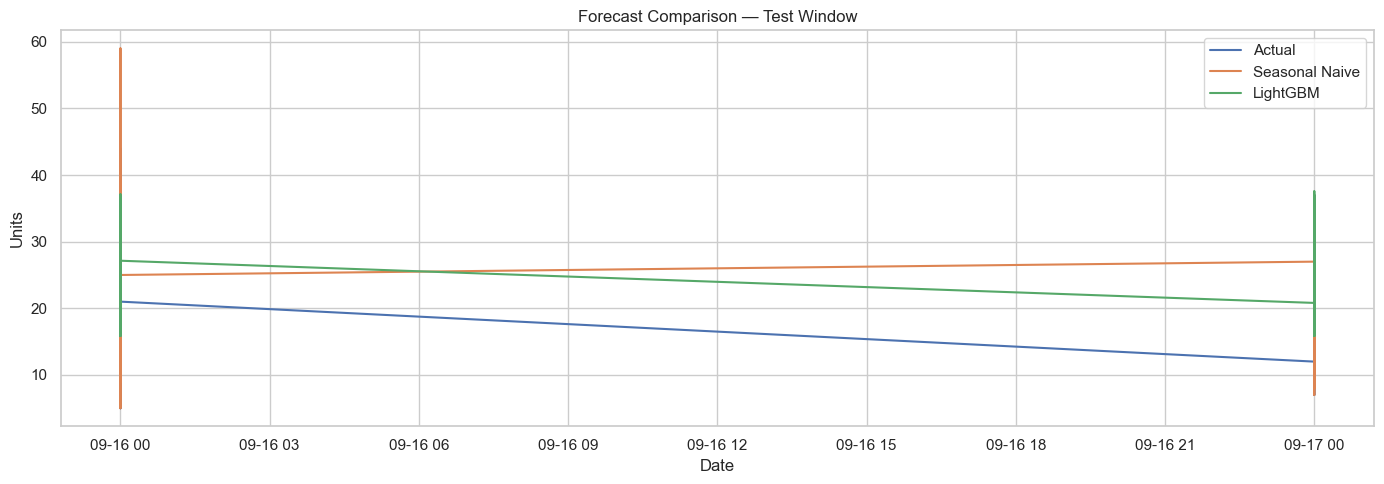

In [8]:
# Cell 7 — Forecast Visualization

plot_n = min(100, len(y_test))

forecast_plot = pd.DataFrame({
    "date": X_test["date"].iloc[:plot_n].to_numpy(),
    "actual": y_test.iloc[:plot_n].to_numpy(),
    "naive": np.asarray(naive_preds)[:plot_n],
    "lightgbm": np.asarray(lgb_preds)[:plot_n],
})

plt.figure(figsize=(14, 5))
plt.plot(
    forecast_plot["date"],
    forecast_plot["actual"],
    label="Actual",
)
plt.plot(
    forecast_plot["date"],
    forecast_plot["naive"],
    label="Seasonal Naive",
)
plt.plot(
    forecast_plot["date"],
    forecast_plot["lightgbm"],
    label="LightGBM",
)
plt.title("Forecast Comparison — Test Window")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

,feature,importance
45,rolling_mean_30,1232
26,day_of_week,896
41,rolling_mean_7,755
43,rolling_mean_14,658
40,lag_28,495
39,lag_21,456
38,lag_14,440
37,lag_7,400
34,cos_month,140
27,month,114


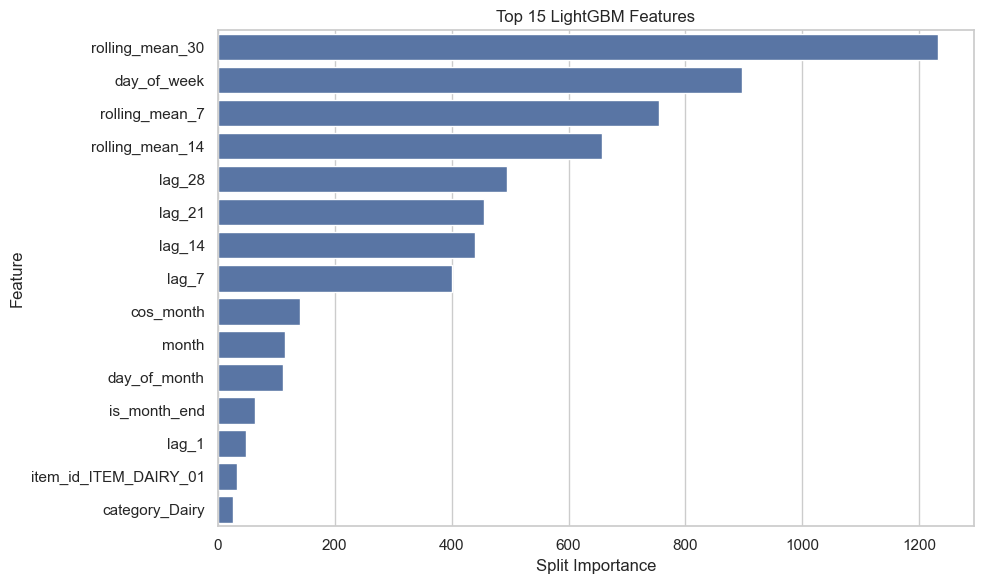

In [9]:
# Cell 8 — Feature Importance

fi_df = lgb_model.feature_importances(top_k=15)

display(fi_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_df,
    x="importance",
    y="feature",
)
plt.title("Top 15 LightGBM Features")
plt.xlabel("Split Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Largest Forecast Errors

error_df = forecast_plot.copy()
error_df["abs_error"] = (
    error_df["actual"] - error_df["lightgbm"]
).abs()

display(
    error_df.sort_values(
        "abs_error",
        ascending=False,
    ).head(10)
)

,date,actual,naive,lightgbm,abs_error
6,2025-09-16,37,39.0,23.075220,13.924780
32,2025-09-16,10,25.0,21.970275,11.970275
31,2025-09-16,6,13.0,17.522918,11.522918
46,2025-09-16,5,9.0,15.865960,10.865960
78,2025-09-17,10,16.0,20.340706,10.340706
75,2025-09-17,7,8.0,17.253239,10.253239
64,2025-09-17,12,27.0,20.807287,8.807287
34,2025-09-16,9,13.0,17.664138,8.664138
55,2025-09-16,8,12.0,16.299572,8.299572
10,2025-09-16,27,15.0,18.822529,8.177471


## Notebook 2 — What you should understand

You should now be able to explain:

1. Why we use chronological validation.
2. Why a seasonal-naive benchmark is necessary.
3. Why lag features are useful for time-series forecasting.
4. Where `random_state` belongs in the current LightGBM wrapper.
5. Why we compare RMSE, MAE and WAPE rather than reporting one number only.